# Function 8 Analysis - Week 12

1. **Function description (unchanged):**  
You're optimising an eight-dimensional black-box function; each parameter influences the output (e.g., performance/accuracy), but the mechanism is unknown. The goal is to maximise the response, so we rely on BO to navigate a likely multi-modal surface while prioritising strong local maxima.

2. **Week 11 evaluated point:** Last week we inadvertently submitted the same point as the week before: `(0.049871, 0.052069, 0.031726, 0.051612, 0.580269, 0.958319, 0.200177, 0.689827)`, and it returned the exact same result (**≈9.7117**).

3. **Analysis of last point:** Because the exact repeat produced the exact same output, this indicates very low observable noise in this local region.

4. **How this changes BO settings:** We do not use a `WhiteKernel` here, so the practical noise control is `alpha` in `GaussianProcessRegressor`. For a low-noise regime, we use a small `alpha` and reduce exploration settings in acquisition (lower `xi`; if using UCB, lower `beta`).

5. **Recommendation for next week (and why):** Run a more exploitative local TuRBO-EI step: tighter trust region, lower `xi`, and mean-dominant ranking around the incumbent basin.


## Loading and Displaying the Data

We load the inputs and outputs for function 8. Week 11 `(0.049871, 0.052069, 0.031726, 0.051612, 0.580269, 0.958319, 0.200177, 0.689827)` returned **≈9.7117** and has been added to the dataset.


In [9]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_8")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Add the new points from Week 1–8
X_new_point_week_1 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.250000, 0.450000]])
y_new_point_week_1 = np.array([9.74365])
X_new_point_week_2 = np.array([[0.100000, 0.100000, 0.100000, 0.100000, 0.100000, 0.400000, 0.250000, 0.450000]])
y_new_point_week_2 = np.array([9.73005])
X_new_point_week_3 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.000000, 1.000000]])
y_new_point_week_3 = np.array([9.6549])
X_new_point_week_4 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.100000, 0.350000]])
y_new_point_week_4 = np.array([9.72465])
X_new_point_week_5 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.210300, 0.700000]])
y_new_point_week_5 = np.array([9.74968782])
X_new_point_week_6 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.306800, 0.700000]])
y_new_point_week_6 = np.array([9.72708752])
X_new_point_week_7 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.220000, 0.710000]])
y_new_point_week_7 = np.array([9.74889])
X_new_point_week_8 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.601973, 0.930000, 0.190000, 0.680000]])
y_new_point_week_8 = np.array([9.7504526536355])
X_new_point_week_9 = np.array([[0.047376, 0.055987, 0.028756, 0.041164, 0.589975, 0.923480, 0.229032, 0.665521]])
y_new_point_week_9 = np.array([9.7395210926704])
X_new_point_week_10 = np.array([[0.049871, 0.052069, 0.031726, 0.051612, 0.580269, 0.958319, 0.200177, 0.689827]])
y_new_point_week_10 = np.array([9.7117260365926])
X_new_point_week_11 = np.array([[0.049871, 0.052069, 0.031726, 0.051612, 0.580269, 0.958319, 0.200177, 0.689827]])
y_new_point_week_11 = np.array([9.7117260365926])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
    X_new_point_week_10,
    X_new_point_week_11,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
    y_new_point_week_10,
    y_new_point_week_11,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,x3,x4,x5,x6,x7,x8,y
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117
5,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748
6,0.908649,0.062250,0.238260,0.766604,0.132336,0.990244,0.688068,0.742496,7.327435
7,0.586371,0.880736,0.745021,0.546035,0.009649,0.748992,0.230907,0.097916,7.299872
8,0.761137,0.854672,0.382124,0.337352,0.689708,0.309853,0.631380,0.041956,7.957875
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


df sorted by y


,x1,x2,x3,x4,x5,x6,x7,x8,y
0,0.050000,0.050000,0.050000,0.050000,0.601973,0.930000,0.190000,0.680000,9.750453
1,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.210300,0.700000,9.749688
2,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.220000,0.710000,9.748890
3,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.250000,0.450000,9.743650
4,0.047376,0.055987,0.028756,0.041164,0.589975,0.923480,0.229032,0.665521,9.739521
5,0.100000,0.100000,0.100000,0.100000,0.100000,0.400000,0.250000,0.450000,9.730050
6,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.306800,0.700000,9.727088
7,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.100000,0.350000,9.724650
8,0.049871,0.052069,0.031726,0.051612,0.580269,0.958319,0.200177,0.689827,9.711726
9,0.049871,0.052069,0.031726,0.051612,0.580269,0.958319,0.200177,0.689827,9.711726


## Weekly Optimization Progress Summary

Overview of all 11 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

- **Week 11 update:** `(0.049871, 0.052069, 0.031726, 0.051612, 0.580269, 0.958319, 0.200177, 0.689827)` → **≈9.7117** (not a new maximum).


In [10]:
# Build weekly progress dataframe from available week variables (auto-detect)
weekly_X, weekly_y = [], []
week_idx = 1
while f'X_new_point_week_{week_idx}' in globals() and f'y_new_point_week_{week_idx}' in globals():
    weekly_X.append(globals()[f'X_new_point_week_{week_idx}'])
    weekly_y.append(globals()[f'y_new_point_week_{week_idx}'])
    week_idx += 1

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'x5': [x[0, 4] for x in weekly_X],
    'x6': [x[0, 5] for x in weekly_X],
    'x7': [x[0, 6] for x in weekly_X],
    'x8': [x[0, 7] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(0)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print('=' * 150)
print('WEEKLY OPTIMIZATION PROGRESS')
print('=' * 150)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f'+{x:.6f}' if pd.notna(x) else '-')
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f}")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,x5,x6,x7,x8,y,Running_Max,Status,Improvement
0,1,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.250000,0.450000,9.743650,9.743650,✓ NEW MAX,+9.743650
1,2,0.100000,0.100000,0.100000,0.100000,0.100000,0.400000,0.250000,0.450000,9.730050,9.743650,✗,-
2,3,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.000000,1.000000,9.654900,9.743650,✗,-
3,4,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.100000,0.350000,9.724650,9.743650,✗,-
4,5,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.210300,0.700000,9.749688,9.749688,✓ NEW MAX,+0.006038
5,6,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.306800,0.700000,9.727088,9.749688,✗,-
6,7,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.220000,0.710000,9.748890,9.749688,✗,-
7,8,0.050000,0.050000,0.050000,0.050000,0.601973,0.930000,0.190000,0.680000,9.750453,9.750453,✓ NEW MAX,+0.000765
8,9,0.047376,0.055987,0.028756,0.041164,0.589975,0.923480,0.229032,0.665521,9.739521,9.750453,✗,-
9,10,0.049871,0.052069,0.031726,0.051612,0.580269,0.958319,0.200177,0.689827,9.711726,9.750453,✗,-



📊 Summary: 3/11 weeks achieved new max (Weeks [1, 5, 8])
   Success rate: 27.3% | Final best: 9.750453


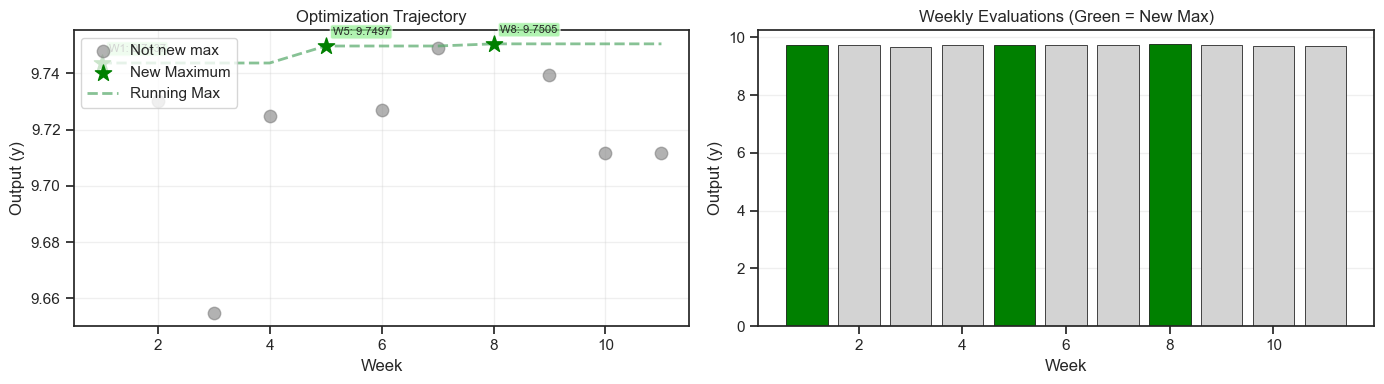

In [11]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [12]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
np.random.seed(42)
# Per-feature lengthscales with bounds (assuming little noise, no WhiteKernel)
kernel = Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(0.2, 5.0),
    nu=2.5
)
# Low alpha to reflect low observed noise (repeat-point check)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)
print("GP fitted successfully")
print("\nGP Kernel Insights:")
print("Lengthscales (one per feature):", gp.kernel_.length_scale)
print("Full kernel parameters:", gp.kernel_.get_params())


GP fitted successfully

GP Kernel Insights:
Lengthscales (one per feature): [1.50303769 2.14087808 1.09632216 3.48865784 5.         2.58030247
 1.58789088 5.        ]
Full kernel parameters: {'length_scale': array([1.50303769, 2.14087808, 1.09632216, 3.48865784, 5.        ,
       2.58030247, 1.58789088, 5.        ]), 'length_scale_bounds': (0.2, 5.0), 'nu': 2.5}


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 4 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Random Forest Analysis: Feature Importance Check

We've been assuming x7 and x8 are the key levers while fixing x1-x4 at 0.05. Let's verify this with a Random Forest to see if we're missing anything.


RANDOM FOREST FEATURE IMPORTANCE
x1: 0.558 ###########################
x3: 0.252 ############
x7: 0.071 ###
x2: 0.045 ##
x4: 0.031 #
x5: 0.020 
x6: 0.013 
x8: 0.010 


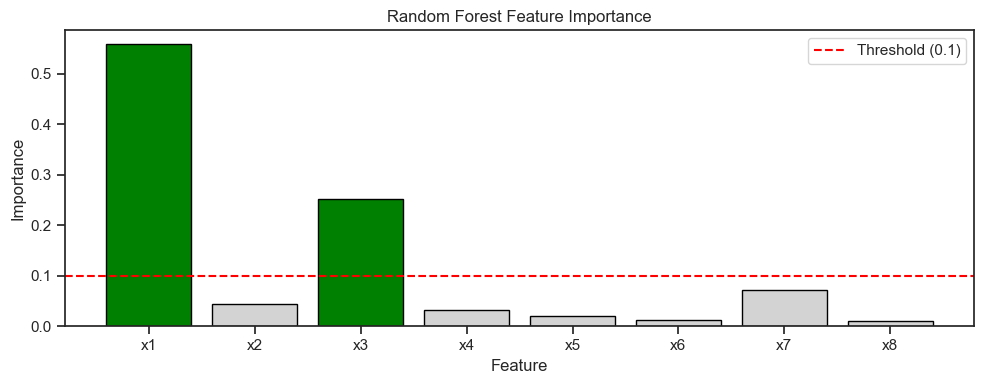


RF-BASED GRID SEARCH

Top 5 RF candidates:
      x1       x2       x3       x4       x5       x6       x7       x8  rf_pred  rf_sigma      ucb
0.049567 0.045598 0.055746 0.034897 0.634283 0.937656 0.223870 0.647865 9.737307  0.031454 9.740452
0.051566 0.058132 0.060586 0.013525 0.633369 0.917728 0.221534 0.620595 9.737102  0.031312 9.740233
0.073973 0.029577 0.054766 0.026985 0.600892 0.907176 0.219992 0.645052 9.733566  0.065402 9.740106
0.050251 0.031092 0.056670 0.047503 0.617730 0.917375 0.207720 0.627907 9.733509  0.065207 9.740030
0.080454 0.005703 0.059418 0.045890 0.597832 0.923384 0.217465 0.650126 9.726021  0.139178 9.739938

RF RECOMMENDATION
x1=0.049567, x2=0.045598, x3=0.055746, x4=0.034897
x5=0.634283, x6=0.937656, x7=0.223870, x8=0.647865
RF prediction: 9.7373 +/- 0.0315

RF SUBMISSION FORMAT
0.049567-0.045598-0.055746-0.034897-0.634283-0.937656-0.223870-0.647865


In [13]:
from sklearn.ensemble import RandomForestRegressor

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Feature importance
feature_names = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']
importances = rf.feature_importances_

print('='*60)
print('RANDOM FOREST FEATURE IMPORTANCE')
print('='*60)
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    bar = '#' * int(imp * 50)
    print(f'{name}: {imp:.3f} {bar}')

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['green' if imp > 0.1 else 'lightgray' for imp in importances]
ax.bar(feature_names, importances, color=colors, edgecolor='black')
ax.set_xlabel('Feature')
ax.set_ylabel('Importance')
ax.set_title('Random Forest Feature Importance')
ax.axhline(y=0.1, color='red', linestyle='--', label='Threshold (0.1)')
ax.legend()
plt.tight_layout()
plt.show()

# RF-based grid search for best point
print('\n' + '='*60)
print('RF-BASED GRID SEARCH')
print('='*60)

# Search bounds - use wider bounds for RF to check if we're missing something
rf_bounds = [
    (0.0, 0.15),   # x1 - test if 0.05 is really best
    (0.0, 0.15),   # x2
    (0.0, 0.15),   # x3
    (0.0, 0.15),   # x4
    (0.55, 0.65),  # x5
    (0.90, 0.96),  # x6
    (0.15, 0.25),  # x7 (around winning value)
    (0.62, 0.74),  # x8 (around winning value)
]

# Generate mesh
n_samples = 50000
np.random.seed(42)
mesh = np.array([[np.random.uniform(lo, hi) for lo, hi in rf_bounds] for _ in range(n_samples)])

# Get RF predictions and uncertainty (via tree disagreement)
rf_preds = rf.predict(mesh)
tree_preds = np.array([tree.predict(mesh) for tree in rf.estimators_])
rf_sigma = tree_preds.std(axis=0)

# UCB with exploration
beta = 0.1  # light exploration
rf_ucb = rf_preds + beta * rf_sigma

# Find top candidates
candidates = pd.DataFrame(mesh, columns=feature_names)
candidates['rf_pred'] = rf_preds
candidates['rf_sigma'] = rf_sigma
candidates['ucb'] = rf_ucb

# Distance filter
def min_dist(row):
    pt = row[feature_names].values
    return np.sqrt(((X - pt)**2).sum(axis=1)).min()

candidates['min_dist'] = candidates.apply(min_dist, axis=1)
candidates_filtered = candidates[candidates['min_dist'] > 0.02].copy()

if len(candidates_filtered) > 0:
    rf_top = candidates_filtered.nlargest(5, 'ucb')
else:
    rf_top = candidates.nlargest(5, 'ucb')

print('\nTop 5 RF candidates:')
print(rf_top[['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'rf_pred', 'rf_sigma', 'ucb']].to_string(index=False))

if len(rf_top) > 0:
    rf_rec = rf_top.iloc[0]
    print(f'\n' + '='*60)
    print('RF RECOMMENDATION')
    print('='*60)
    print(f'x1={rf_rec["x1"]:.6f}, x2={rf_rec["x2"]:.6f}, x3={rf_rec["x3"]:.6f}, x4={rf_rec["x4"]:.6f}')
    print(f'x5={rf_rec["x5"]:.6f}, x6={rf_rec["x6"]:.6f}, x7={rf_rec["x7"]:.6f}, x8={rf_rec["x8"]:.6f}')
    print(f'RF prediction: {rf_rec["rf_pred"]:.4f} +/- {rf_rec["rf_sigma"]:.4f}')
    
    print(f'\n' + '='*60)
    print('RF SUBMISSION FORMAT')
    print('='*60)
    print(f'{rf_rec["x1"]:.6f}-{rf_rec["x2"]:.6f}-{rf_rec["x3"]:.6f}-{rf_rec["x4"]:.6f}-{rf_rec["x5"]:.6f}-{rf_rec["x6"]:.6f}-{rf_rec["x7"]:.6f}-{rf_rec["x8"]:.6f}')


## Finding the Next Point to Evaluate (more exploitative TuRBO-EI search)

Given the low-noise repeat-point evidence, we tighten the trust-region and lower EI exploration pressure. This keeps the search anchored near the incumbent basin and prioritizes mean-dominant local improvement, while still keeping a minimum-distance filter to avoid re-testing near-duplicates.


In [14]:
from scipy.stats import norm

# TuRBO-style local trust region + EI
rng = np.random.default_rng(42)

# Current best point
y_best = y.max()
best_idx = y.argmax()
best_point = X[best_idx].copy()

print(f"Current best score: {y_best:.6f}")
print(f"Current best point: {best_point}")

# Tighter trust region centered at incumbent (more exploitative)
trust_radius = np.array([0.04, 0.04, 0.04, 0.04, 0.05, 0.04, 0.05, 0.05])
lb = np.maximum(0.0, best_point - trust_radius)
ub = np.minimum(1.0, best_point + trust_radius)

print("\nTuRBO trust region bounds:")
for i in range(8):
    print(f"  x{i+1}: [{lb[i]:.4f}, {ub[i]:.4f}]")

# Sample candidates in trust region
n_cand = 60000
cand = rng.uniform(lb, ub, size=(n_cand, 8))

# EI acquisition in trust region (lower xi for more exploitative search)
xi = 0.005
mu, sigma = gp.predict(cand, return_std=True)
sigma_safe = np.maximum(sigma, 1e-9)
improvement = mu - y_best - xi
z = improvement / sigma_safe
ei = improvement * norm.cdf(z) + sigma_safe * norm.pdf(z)
ei[sigma <= 1e-9] = 0.0

# Distance filter to avoid replaying old points
dist = np.sqrt(((cand[:, None, :] - X[None, :, :])**2).sum(axis=2))
min_dist = dist.min(axis=1)
mask = min_dist >= 0.01
cand = cand[mask]
mu = mu[mask]
sigma = sigma[mask]
ei = ei[mask]

# Best EI in trust region
idx = np.argmax(ei)
next_point = cand[idx]
mu_pred = np.array([mu[idx]])
sigma_pred = np.array([sigma[idx]])

print(f"\n{'='*60}")
print("TURBO-EI RECOMMENDATION")
print(f"{'='*60}")
print("\nNext point to evaluate:")
print(f"  x1={next_point[0]:.6f}, x2={next_point[1]:.6f}, x3={next_point[2]:.6f}, x4={next_point[3]:.6f}")
print(f"  x5={next_point[4]:.6f}, x6={next_point[5]:.6f}, x7={next_point[6]:.6f}, x8={next_point[7]:.6f}")
print(f"\nPredicted output: {mu_pred[0]:.4f} +/- {sigma_pred[0]:.4f}")
print(f"Expected Improvement: {ei[idx]:.6f}")

print(f"\n{'='*60}")
print("TURBO-EI SUBMISSION FORMAT")
print(f"{'='*60}")
print(f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}-{next_point[4]:.6f}-{next_point[5]:.6f}-{next_point[6]:.6f}-{next_point[7]:.6f}")



Current best score: 9.750453
Current best point: [0.05     0.05     0.05     0.05     0.601973 0.93     0.19     0.68    ]

TuRBO trust region bounds:
  x1: [0.0100, 0.0900]
  x2: [0.0100, 0.0900]
  x3: [0.0100, 0.0900]
  x4: [0.0100, 0.0900]
  x5: [0.5520, 0.6520]
  x6: [0.8900, 0.9700]
  x7: [0.1400, 0.2400]
  x8: [0.6300, 0.7300]

TURBO-EI RECOMMENDATION

Next point to evaluate:
  x1=0.011639, x2=0.083291, x3=0.089482, x4=0.012930
  x5=0.621958, x6=0.890087, x7=0.224722, x8=0.712482

Predicted output: 9.8176 +/- 0.0293
Expected Improvement: 0.062345

TURBO-EI SUBMISSION FORMAT
0.011639-0.083291-0.089482-0.012930-0.621958-0.890087-0.224722-0.712482


## Distance Analysis of Recommended Point

We calculate the Euclidean distance from the recommended point to all existing observations. This helps us understand how similar the recommended point is to our existing data. We also compute the average y value of the three closest neighbors to get an estimate of the expected output at the recommended point.


In [15]:
distances = np.sqrt(((X - next_point)**2).sum(axis=1))
df_dist = pd.DataFrame({"point_index": range(len(X)), "distance": distances, "y": y})
df_dist = df_dist.sort_values("distance")
print("Euclidean distances from recommended point to all observations:")
print(df_dist.to_string(index=False))
closest_3 = df_dist.head(3)
avg_y = closest_3["y"].mean()
print(f"\nThree closest neighbors: points {closest_3['point_index'].tolist()}")
print(f"Average y value of closest 3 neighbors: {avg_y:.4f}")


Euclidean distances from recommended point to all observations:
 point_index  distance        y
          46  0.087272 9.748890
          44  0.089173 9.749688
          47  0.098823 9.750453
          48  0.104256 9.739521
          45  0.120336 9.727088
          49  0.121564 9.711726
          50  0.121564 9.711726
          40  0.277712 9.743650
          42  0.375172 9.654900
          43  0.393112 9.724650
          14  0.406154 9.598482
          22  0.754434 9.141639
          41  0.773265 9.730050
          26  0.964330 9.344274
          23  1.066476 8.817558
          31  1.067548 8.421759
          32  1.073591 8.278062
           5  1.089426 8.541748
          39  1.113613 9.183005
          30  1.160005 7.923759
          35  1.166231 8.472936
          12  1.185938 8.976554
          25  1.204279 8.830745
           0  1.211322 7.398721
           4  1.241608 8.606117
          10  1.265722 7.854541
          28  1.270209 8.042213
          38  1.290272 7.436594
        

**Current best:** `0.050000-0.050000-0.050000-0.050000-0.602000-0.930000-0.190000-0.680000` (≈9.7505)

**Week 11 evaluated point:** `0.049871-0.052069-0.031726-0.051612-0.580269-0.958319-0.200177-0.689827` → ≈9.7117 (high, but not a new maximum).

**Proposed next point (submission format):** use the exploitative TuRBO-EI output printed above.

Because the repeated-point check indicates very low local noise, we now use a tighter trust region and lower EI exploration pressure (`xi`) to prioritize mean-dominant local improvement around the incumbent basin.


In [16]:
# ============================================================
# FINAL DECISION: TuRBO-EI local trust region
# ============================================================

print('='*70)
print('FINAL DECISION: TuRBO-style trust region + EI')
print('='*70)

# Final point = TuRBO-EI recommendation from cell above
final_point = np.array(next_point)
final_gp_mu = gp.predict(final_point.reshape(1, -1))[0]
final_rf_mu = rf.predict(final_point.reshape(1, -1))[0]

print('\nRationale:')
print('  1. Repeated-point check suggests very low observable local noise.')
print('  2. We use a tighter TuRBO trust region around the incumbent (more exploitative).')
print('  3. Lower-xi EI selects mean-dominant local improvement candidates.')

print('\nModel cross-check at chosen point:')
print(f'  GP prediction: {final_gp_mu:.4f}')
print(f'  RF prediction: {final_rf_mu:.4f}')

print('\n' + '='*70)
print('FINAL SUBMISSION FORMAT (TURBO-EI)')
print('='*70)
print(f'\n{final_point[0]:.6f}-{final_point[1]:.6f}-{final_point[2]:.6f}-{final_point[3]:.6f}-{final_point[4]:.6f}-{final_point[5]:.6f}-{final_point[6]:.6f}-{final_point[7]:.6f}')
print('\n' + '='*70)



FINAL DECISION: TuRBO-style trust region + EI

Rationale:
  1. Repeated-point check suggests very low observable local noise.
  2. We use a tighter TuRBO trust region around the incumbent (more exploitative).
  3. Lower-xi EI selects mean-dominant local improvement candidates.

Model cross-check at chosen point:
  GP prediction: 9.8176
  RF prediction: 9.6541

FINAL SUBMISSION FORMAT (TURBO-EI)

0.011639-0.083291-0.089482-0.012930-0.621958-0.890087-0.224722-0.712482



In [17]:
# Final quick reference: current best observed point
best_idx = int(np.argmax(y))
best_point = X[best_idx]
best_score = float(y[best_idx])

print('CURRENT BEST POINT')
print('-' * 40)
print(f"x1={best_point[0]:.6f}, x2={best_point[1]:.6f}, x3={best_point[2]:.6f}, x4={best_point[3]:.6f}")
print(f"x5={best_point[4]:.6f}, x6={best_point[5]:.6f}, x7={best_point[6]:.6f}, x8={best_point[7]:.6f}")
print(f"Best score y={best_score:.6f}")
print(f"Submission format: {best_point[0]:.6f}-{best_point[1]:.6f}-{best_point[2]:.6f}-{best_point[3]:.6f}-{best_point[4]:.6f}-{best_point[5]:.6f}-{best_point[6]:.6f}-{best_point[7]:.6f}")

CURRENT BEST POINT
----------------------------------------
x1=0.050000, x2=0.050000, x3=0.050000, x4=0.050000
x5=0.601973, x6=0.930000, x7=0.190000, x8=0.680000
Best score y=9.750453
Submission format: 0.050000-0.050000-0.050000-0.050000-0.601973-0.930000-0.190000-0.680000
